In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import glob
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import matplotlib.image as mpimg
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint


In [20]:
filepath = 'dataset/'
filelist = sorted(glob.glob(filepath+'*jpg'))
print(len(filelist))
print(filelist[0])

1100
dataset\cat.0.jpg


In [22]:
def Normalize(img):
    if np.max(img) != np.min(img):
        return (img - np.min(img))/(np.max(img) - np.min(img))
    else:
        return img

In [27]:
cat_img = []
dog_img = []
for i in range(len(filelist)):
    filename = filelist[i].split('/')[-1]
    if "cat" in filename:
        img = Image.open(filelist[i]).convert('L').resize((128,128))
        img = np.array(img,dtype = np.uint8)
        img = Normalize(img)
        img = np.expand_dims(img,axis =2)
        cat_img.append(img)
    elif "dog" in filename:
        img = Image.open(filelist[i]).convert('L').resize((128,128))
        img = np.array(img,dtype = np.uint8)
        img = Normalize(img)
        img = np.expand_dims(img,axis =2)
        dog_img.append(img)
    else:
        print('unsopported type image', filelist[i])
cat_img = np.array(cat_img)
dog_img = np.array(dog_img)
print(np.shape(cat_img))
print(np.shape(dog_img))

(550, 128, 128, 1)
(550, 128, 128, 1)


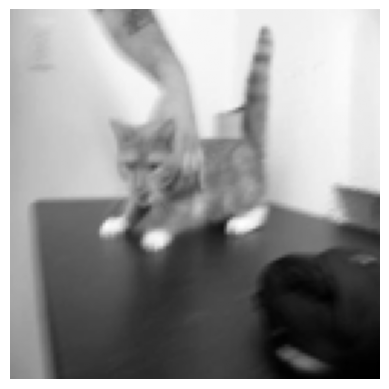

interactive(children=(IntSlider(value=0, description='img_index', max=549), Output()), _dom_classes=('widget-i…

In [38]:
def show_img(img_index):
    plt.imshow(cat_img[img_index,:,:,0], cmap='gray')
    plt.axis('off') 
    plt.show()

slider = widgets.IntSlider(value=0, min=0, max=len(cat_img)-1, step=1)
widgets.interactive(show_img, img_index=slider)

In [39]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)